# Importing libraries

In [63]:
import random
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Brute Force

In [55]:
def brute_force_search(text: str, pattern: str):
    n, m = len(text), len(pattern)
    positions = []
    comparisons = 0

    if m == 0:
        return list(range(n + 1)), comparisons

    for i in range(n - m + 1):
        j = 0
        while j < m:
            comparisons += 1
            if text[i + j] != pattern[j]:
                break
            j += 1

        if j == m:
            positions.append(i)

    return positions, comparisons


# KMP

In [56]:
def compute_lps(pattern: str):
    """
    LPS = longest proper prefix which is also suffix
    Returns:
        lps array
        preprocessing comparisons
    """
    m = len(pattern)
    lps = [0] * m
    length = 0
    i = 1
    comparisons = 0

    while i < m:
        comparisons += 1
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1

    return lps, comparisons


def kmp_search(text: str, pattern: str):
    n, m = len(text), len(pattern)
    positions = []

    if m == 0:
        return list(range(n + 1)), 0

    lps, preprocessing_comparisons = compute_lps(pattern)

    i = 0  # index for text
    j = 0  # index for pattern
    comparisons = 0

    while i < n:
        comparisons += 1
        if text[i] == pattern[j]:
            i += 1
            j += 1

            if j == m:
                positions.append(i - j)
                j = lps[j - 1]
        else:
            if j != 0:
                j = lps[j - 1]
            else:
                i += 1

    return positions, comparisons + preprocessing_comparisons

# BMH

In [57]:
def build_shift_table(pattern: str):
    m = len(pattern)
    shift = {}

    # default shift = m (handled with dict.get later)
    for i in range(m - 1):
        shift[pattern[i]] = m - 1 - i

    return shift


def bmh_search(text: str, pattern: str):
    n, m = len(text), len(pattern)
    positions = []
    comparisons = 0

    if m == 0:
        return list(range(n + 1)), comparisons

    shift = build_shift_table(pattern)
    i = 0

    while i <= n - m:
        j = m - 1

        while j >= 0:
            comparisons += 1
            if text[i + j] != pattern[j]:
                break
            j -= 1

        if j < 0:
            positions.append(i)
            i += 1   # move by 1 to allow overlapping matches
        else:
            i += shift.get(text[i + m - 1], m)

    return positions, comparisons


# Test data

In [91]:
def generate_random_dna(length: int):
    return ''.join(random.choice("ACGT") for _ in range(length))


short_text = ("the quick brown fox jumps over the lazy dog " * 3)[:105]
long_text = ("the quick white elephant jumps over the lazy cat and scared the monkey " * 23)[:1005]
repetative_text = ("ABCDEFGHAAAAAAAAABDCABCDFGH"*20)[:500]

random.seed(42)
random_text = generate_random_dna(1000)

test_cases = [
    ("Short text", short_text, ["quick", "lazy", "fox jumps"]),
    ("Random DNA", random_text, ["ACG", "TTGA", "CCCCA"]),
    ("Long text", long_text, ["quick brown", "lazy dog", "notfound"]),
    ("Rep. pattern", repetative_text, ["AAAAAAAAABDC"])
]

algorithms = {
    "Brute Force": brute_force_search,
    "KMP": kmp_search,
    "BMH": bmh_search,
}


# Run tests

In [92]:
results = []

for text_name, text, patterns in test_cases:
    for pattern in patterns:
        reference_positions = None

        for algo_name, algo_func in algorithms.items():
            positions, comparisons = algo_func(text, pattern)

            # Optional correctness check
            if reference_positions is None:
                reference_positions = positions
            else:
                assert positions == reference_positions, (
                    f"Mismatch in {algo_name} for pattern '{pattern}'"
                )

            results.append({
                "Text Type": text_name,
                "Text Length": len(text),
                "Pattern": pattern,
                "Pattern Length": len(pattern),
                "Algorithm": algo_name,
                "Matches Found": len(positions),
                "Positions": positions,
                "Character Comparisons": comparisons
            })

df = pd.DataFrame(results)

print("=== RESULTS TABLE ===")
print()
display(df[["Text Type", "Pattern", "Algorithm", "Character Comparisons", "Matches Found"]])


=== RESULTS TABLE ===



,Text Type,Pattern,Algorithm,Character Comparisons,Matches Found
0,Short text,quick,Brute Force,113,3
1,Short text,quick,KMP,109,3
2,Short text,quick,BMH,36,3
3,Short text,lazy,Brute Force,108,2
4,Short text,lazy,KMP,108,2
5,Short text,lazy,BMH,34,2
6,Short text,fox jumps,Brute Force,113,2
7,Short text,fox jumps,KMP,113,2
8,Short text,fox jumps,BMH,33,2
9,Random DNA,ACG,Brute Force,1310,22


# Visualization 

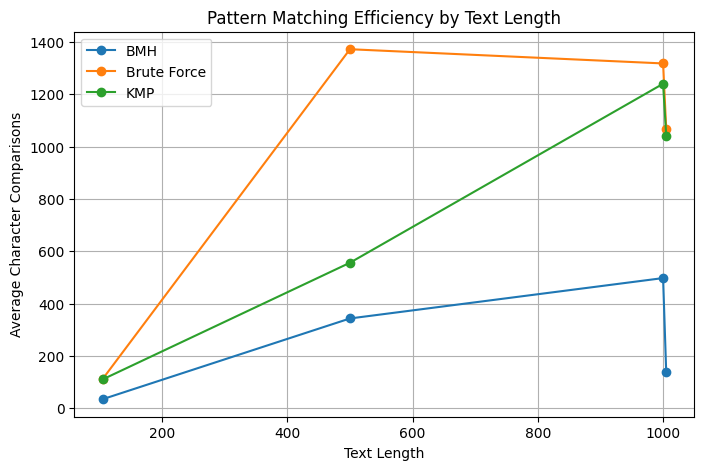

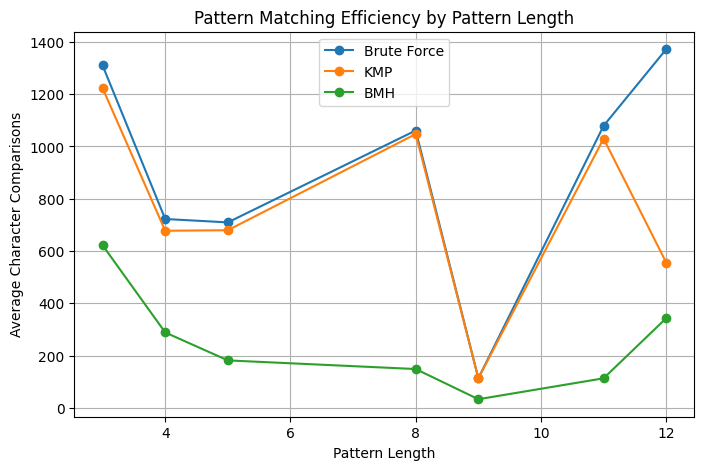

In [98]:
grouped = (
    df.groupby(["Text Length", "Algorithm"])["Character Comparisons"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
for algo in grouped["Algorithm"].unique():
    subset = grouped[grouped["Algorithm"] == algo]
    plt.plot(subset["Text Length"], subset["Character Comparisons"], marker="o", label=algo)

plt.xlabel("Text Length")
plt.ylabel("Average Character Comparisons")
plt.title("Pattern Matching Efficiency by Text Length")
plt.legend()
plt.grid(True)
plt.show()


# 7. EXTRA VISUALIZATION BY PATTERN LENGTH
plt.figure(figsize=(8, 5))
for algo in df["Algorithm"].unique():
    subset = df.groupby(["Pattern Length", "Algorithm"])["Character Comparisons"].mean().reset_index()
    subset = subset[subset["Algorithm"] == algo]
    plt.plot(subset["Pattern Length"], subset["Character Comparisons"], marker="o", label=algo)

plt.xlabel("Pattern Length")
plt.ylabel("Average Character Comparisons")
plt.title("Pattern Matching Efficiency by Pattern Length")
plt.legend()
plt.grid(True)
plt.show()